In [1]:
# 변수의 shape, type, value 확인
def p(var,_name="") :
    if _name != "" : print(f'<<{_name}>>')
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}')

# LangSmith 사용해 보기

In [2]:
%%time
# !pip install -q langgraph langchain-openai langsmith langchain-teddynote -q
# # google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.

!pip install --prefer-binary langgraph==0.4.0 langchain-openai==0.3.33 langchain-community==0.3.30 langsmith -q
!pip install --no-deps "langchain-teddynote==0.3.42" -q
#google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.9/148.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━

In [3]:
!pip list | grep -E "langchain|langgraph|langchain-openai|langsmith|langchain-teddynote"
# 2510
# langchain                             0.3.27
# langchain-core                        0.3.78
# langchain-openai                      0.3.35
# langchain-teddynote                   0.5.1
# langchain-text-splitters              0.3.11
# langgraph                             0.6.10
# langgraph-checkpoint                  2.1.2
# langgraph-prebuilt                    0.6.4
# langgraph-sdk                         0.2.9
# langsmith                             0.4.33

# 2601
# langchain                                0.3.27
# langchain-community                      0.3.30
# langchain-core                           0.3.83
# langchain-openai                         0.3.33
# langchain-teddynote                      0.3.42
# langchain-text-splitters                 0.3.11
# langgraph                                0.4.0
# langgraph-checkpoint                     2.1.2
# langgraph-prebuilt                       1.0.1
# langgraph-sdk                            0.3.3
# langsmith                                0.6.4

langchain                                0.3.27
langchain-community                      0.3.30
langchain-core                           0.3.83
langchain-openai                         0.3.33
langchain-teddynote                      0.3.42
langchain-text-splitters                 0.3.11
langgraph                                0.4.0
langgraph-checkpoint                     2.1.2
langgraph-prebuilt                       1.0.1
langgraph-sdk                            0.3.3
langsmith                                0.6.4


In [4]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_TRACING"] = 'true'          # 구버전 호환을 위해
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_ENDPOINT"] = 'https://api.smith.langchain.com'
os.environ["LANGSMITH_PROJECT"] = "LangSmith-Demo"# 프로젝트명

In [5]:
from typing import TypedDict, List
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langchain_teddynote.graphs import visualize_graph
from langsmith import traceable   # 노드별 span을 더 자세하게 보임

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## LLM, Tool 정의  
**env 설정 이후에 langchain_openai, langgraph를 import 해야 함**

In [6]:
# LLM 정의
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Tool 정의
## @traceable
# 함수, node의 동작이 Trace에 더 자세하게 표시됨
@traceable
def get_parameter_from_db(step_name: str) -> str:
    print(f"--- TOOL: get_parameter_from_db(step_name='{step_name}') 실행 ---")
    db = {"포토리소그래피": "Dose: 25.0, Focus: -0.05", "식각": "Power: 500, Pressure: 10"}
    return db.get(step_name, "해당 공정 데이터를 찾을 수 없습니다.")

# 데이터에 'Dose' 파라미터가 포함되어 있는지 검사하는 품질 검사 툴
@traceable
def quality_check(data: str) -> bool:
    print(f"--- TOOL: quality_check(data='{data}') 실행 ---")
    return "Dose" in data

print("실습용 LLM 및 도구 준비 완료.")

실습용 LLM 및 도구 준비 완료.


## Cloud로 보내서 시각화 : https://smith.langchain.com/

In [7]:
# 그래프의 상태 정의
class AgentState(TypedDict):
    query: str
    tool_output: str
    quality_ok: bool

@traceable
def input_node(state: AgentState) -> dict:
    print("--- 노드 실행: input_node ---")
    # 실제로는 여기서 LLM으로 쿼리에서 step_name을 추출해야 하지만, 단순화를 위해 직접 사용
    return {"query": state['query']}

@traceable
def execution_node(state: AgentState) -> dict:
    print("--- 노드 실행: execution_node ---")
    result = get_parameter_from_db(state['query'])
    return {"tool_output": result}

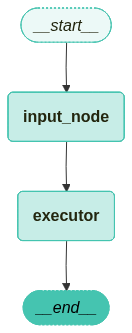

In [8]:
# 기본 그래프 생성 (executor -> END)
base_workflow = StateGraph(AgentState)
base_workflow.set_entry_point("input_node")
base_workflow.add_node("input_node", input_node)
base_workflow.add_node("executor", execution_node)
base_workflow.add_edge("input_node", "executor")
base_workflow.add_edge("executor", END)

app = base_workflow.compile()
visualize_graph(app)

In [9]:
# os.environ["LANGSMITH_PROJECT"] = "LangSmith-Demo"# 프로젝트명
# 프로젝트명으로 프로젝트 생성 및 기본 정보 저장
# run Name "LangGraph"
app.invoke({"query": "포토리소그래피"})

--- 노드 실행: input_node ---
--- 노드 실행: execution_node ---
--- TOOL: get_parameter_from_db(step_name='포토리소그래피') 실행 ---


{'query': '포토리소그래피', 'tool_output': 'Dose: 25.0, Focus: -0.05'}

In [10]:
## 지정된 run_name으로 저장
result = app.invoke(
    {"query": "포토리소그래피"},
    config={
        "run_name": "Photolithography-Demo",        # LangSmith Run 이름
        "tags": ["demo", "langsmith"],
        "metadata": {"dataset":"n/a", "env":"colab"}# 임의 메타데이터
    }
)

print("\n--- 최종 실행 결과 ---")
print(result)

--- 노드 실행: input_node ---
--- 노드 실행: execution_node ---
--- TOOL: get_parameter_from_db(step_name='포토리소그래피') 실행 ---

--- 최종 실행 결과 ---
{'query': '포토리소그래피', 'tool_output': 'Dose: 25.0, Focus: -0.05'}


In [11]:
app.invoke(
    {"query": "내일의 날씨는?"},
    config={
        "run_name": "Photolithography-Demo",  # LangSmith Run 이름
        "tags": ["demo", "langsmith"],
        "metadata": {"dataset":"n/a", "env":"colab"}  # 임의 메타데이터
    }
)

--- 노드 실행: input_node ---
--- 노드 실행: execution_node ---
--- TOOL: get_parameter_from_db(step_name='내일의 날씨는?') 실행 ---


{'query': '내일의 날씨는?', 'tool_output': '해당 공정 데이터를 찾을 수 없습니다.'}

#  LangFuse : Local Sever에서 작동하기 위한 대안    
1. LangFuse Cloud(https://cloud.langfuse.com)에 가입(us/eu), api key 받아오기: **개인계정** 사용하세요.    
2. LangFuse Cloud에 로그인,
→ Project > Traces 메뉴에 방금 실행한 chain.run이 자동으로 기록  
https://us.cloud.langfuse.com    
(Doc.: https://langfuse.com/guides/cookbook/integration_langgraph )   
  

In [ ]:
## Colab에서는 docker가 실행되지 않음. 다른 local server에 설치 하세요.
#docker run -d --name langfuse -p 3000:3000 langfuse/langfuse
# 브라우저에서 http://<서버IP>:3000 접속 → 프로젝트 만들고 키 발급

# os.environ["LANGFUSE_PUBLIC_KEY"] = "pk_원격서버에서_발급"
# os.environ["LANGFUSE_SECRET_KEY"] = "sk_원격서버에서_발급"
# os.environ["LANGFUSE_HOST"] = "http://<퍼블릭-URL-또는-서버IP>:3000"  # ngrok/CF Tunnel 주소 가능

In [12]:
!pip install langfuse -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.0/417.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.2 MB/s eta 0:00:00


In [13]:
os.environ["LANGFUSE_PUBLIC_KEY"] = userdata.get('LANGFUSE_PUBLIC_KEY')
os.environ["LANGFUSE_SECRET_KEY"] = userdata.get('LANGFUSE_SECRET_KEY')
os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com"

In [14]:
from langchain_openai import ChatOpenAI
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate

In [15]:
from langfuse.langchain import CallbackHandler
# LangFuse Tracer 활성화
lf_handler = CallbackHandler()

### LangChain 적용

In [17]:
#llm = ChatOpenAI(model_name="gpt-5-mini")
prompt = ChatPromptTemplate.from_template("반도체 공정 중 {process} 단계를 2문장으로 설명해줘.")
chain = prompt | llm
response = chain.invoke({
    "process": "포토리소그래피"},
    config={"callbacks": [lf_handler]})
print(response.content)

포토리소그래피 단계는 반도체 웨이퍼에 감광성 물질인 포토레지스트를 도포한 후, 특정 패턴의 빛을 비춰서 원하는 형태로 노광하는 과정입니다. 이후 화학적 현상을 통해 노광된 부분과 노광되지 않은 부분을 구분하여, 웨이퍼에 미세한 회로 패턴을 형성하는 중요한 단계입니다.


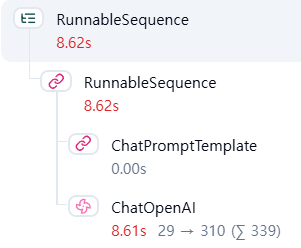  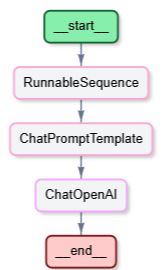

### Meta Data 사용

In [18]:
## Meta Data 넣기 ##
response = chain.invoke(
    {"process": "포토리소그래피"},
    config={
        "callbacks": [lf_handler],
        "run_name": "LangChain한글-Demo",
        "metadata": {
            "langfuse_user_id": "연구소A03",     # 지정된 name
            "langfuse_session_id": "session-1", # 지정된 name
            "langfuse_tags": ["tag-1", "tag-2"],# 지정된 name
            "새로운정보": "넣어보자"
        }
    }
)
print(response.content)

포토리소그래피 단계는 반도체 웨이퍼에 감광성 물질인 포토레지스트를 도포한 후, 특정 패턴의 빛을 비춰서 포토레지스트를 노출시키는 과정입니다. 노출된 포토레지스트는 화학적으로 변화하여 원하는 패턴을 형성하고, 이후 현상 과정을 통해 불필요한 부분이 제거되어 웨이퍼에 미세한 구조가 남게 됩니다.


### LangGraph 적용

In [19]:
## 앞에서 만든 LangGraph app을 실행해 보자
app.invoke(
    {"query": "포토리소그래피"},
    config={
        "callbacks": [lf_handler],
        "run_name": "LangGraph-Demo",
        "metadata": {
            "langfuse_user_id": "user00",
            "langfuse_session_id": "session-1",
            "langfuse_tags": ["tag-1", "tag-2"]
        }
    }
)

--- 노드 실행: input_node ---
--- 노드 실행: execution_node ---
--- TOOL: get_parameter_from_db(step_name='포토리소그래피') 실행 ---


{'query': '포토리소그래피', 'tool_output': 'Dose: 25.0, Focus: -0.05'}

## 복잡한 구조를 trace해 보자

In [20]:
from typing import TypedDict, List, Optional
import time

# LangGraph용 상태 정의
class AgentState(TypedDict, total=False):
    query: str
    rewritten_query: str
    docs: List[str]
    tool_output: str
    quality_ok: bool
    retries: int
    answer: str

# 아주 단순한 "DB" 흉내 (키워드 매칭)
FAKE_DB = {
    "포토리소그래피": [
        "포토레지스트(PR)를 웨이퍼에 코팅하고, 마스크를 통해 노광(Exposure)한다.",
        "현상(Develop)으로 노광된 영역을 제거하여 패턴을 형성한다.",
        "에칭(Etch)과 스트립(Strip) 단계를 통해 회로 패턴을 완성한다.",
    ],
    "식각": [
        "식각(Etch)은 원하는 패턴만 남기도록 재료를 제거하는 과정이다.",
        "건식식각(플라즈마)과 습식식각(액체 화학)을 사용한다.",
    ],
}

def retrieve_from_fake_db(q: str) -> List[str]:
#    time.sleep(0.1)  # 지연 흉내
    hits = []
    for k, docs in FAKE_DB.items():
        if k in q:
            hits.extend(docs)
    return hits[:5]


In [21]:
from langgraph.graph import StateGraph, END

# 입력 노드
def input_node(state: AgentState) -> AgentState:
    return {"query": state["query"], "retries": state.get("retries", 0)}

# 질의 보강 (LLM 호출 → 동의어/영문 보강)
def rewrite_query_node(state: AgentState) -> AgentState:
    user_q = state["query"]
    sys = "너는 반도체 공정 전문가야. 사용자 질의를 검색 친화적으로 정제해줘."
    prompt = f"입력 질의: {user_q}\n\n동의어/영문 병기 등을 추가해서 더 검색 가능한 형태로 한 줄로 만들어줘."
    resp = llm.invoke([{"role":"system", "content":sys},
                       {"role":"user", "content":prompt}])
    return {"rewritten_query": resp.content.strip()}

# 검색/도구 실행 + 간단 요약(LLM), Trace 노출을 위해 LLM 한번 더 호출
def retrieve_node(state: AgentState) -> AgentState:
    q = state.get("rewritten_query") or state["query"]
    docs = retrieve_from_fake_db(q)
    tool_output = "\n".join(f"- {d}" for d in docs) if docs else "(no hits)"

    # 요약(LLM): 도구 결과를 요약하면 LangFuse에 span이 남음
    sys = "너는 반도체 공정 문서 요약가야. 매우 간결히 요약해줘."
    prompt = f"다음 검색 결과를 한 문장으로 요약:\n{tool_output}"
    resp = llm.invoke([{"role":"system","content":sys},
                       {"role":"user","content":prompt}])
    return {"docs": docs, "tool_output": resp.content.strip()}

# retrive 결과 검증(LLM): 충분한 근거가 있는지
def quality_check_node(state: AgentState) -> AgentState:
    q = state["query"]
    docs = state.get("docs", [])
    # 규칙 + LLM 혼합: 문서가 비었으면 바로 false
    if not docs:
        return {"quality_ok": False}

    sys = "너는 품질 검사자야. 주어진 쿼리에 대해 아래 근거들이 충분한지 yes/no만 출력해."
    prompt = f"쿼리: {q}\n근거들:\n- " + "\n- ".join(docs) + "\n\n충분하면 yes, 아니면 no."
    resp = llm.invoke([{"role":"system","content":sys},
                       {"role":"user","content":prompt}])
    ok = "yes" in resp.content.lower()
    return {"quality_ok": True}

# 정보 품질 부족시 query 다시 보강
def refine_query_node(state: AgentState) -> AgentState:
    user_q = state["query"]
    prev = state.get("rewritten_query") or user_q
    sys = "너는 검색전문가야. 주어진 질의를 더 명확하고 검색 친화적으로 재작성해줘."
    prompt = f"기존 질의: {prev}\n\n키워드 보강/동의어 추가/한영 병기를 포함하여 한 줄로 재작성."
    resp = llm.invoke([{"role":"system","content":sys},
                       {"role":"user","content":prompt}])
    return {"rewritten_query": resp.content.strip(), "retries": state.get("retries",0)+1}

# 최종 답변 정리(LLM)
def answer_node(state: AgentState) -> AgentState:
    q = state["query"]
    docs = state.get("docs", [])
    sys = "너는 반도체 공정 전문가야. 한국어로 정확하고 간결하게 답해줘."
    prompt = f"사용자 질문: {q}\n근거:\n- " + "\n- ".join(docs) + "\n\n핵심만 3문장 이내로."
    resp = llm.invoke([{"role":"system","content":sys},
                       {"role":"user","content":prompt}])
    return {"answer": resp.content.strip()}

# 일반 답변(LLM): 내부 정보 검색에서 반복 실패 시
def fallback_answer_node(state: AgentState) -> AgentState:
    q = state["query"]
    sys = "너는 반도체 공정 전문가야. 근거가 부족할 때는 일반 원리를 간단히 설명해줘."
    prompt = f"질문: {q}\n근거 부족. 일반적인 개요를 2~3문장으로 제공."
    resp = llm.invoke([{"role":"system","content":sys},
                       {"role":"user","content":prompt}])
    return {"answer": resp.content.strip()}

# 분기: 품질검사 → OK면 answer, 아니면 refine 또는 fallback
def route_after_quality(state: AgentState) -> str:
    if state.get("quality_ok"):
        return "ok"
    if state.get("retries",0) < 2:
        return "refine"
    return "fallback"

In [22]:
workflow = StateGraph(AgentState)
workflow.set_entry_point("input")

workflow.add_node("input", input_node)
workflow.add_node("rewrite", rewrite_query_node)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("quality", quality_check_node)
workflow.add_node("refine", refine_query_node)
workflow.add_node("generate_answer", answer_node) # Renamed node to avoid conflict
workflow.add_node("fallback", fallback_answer_node)

workflow.add_edge("input", "rewrite")
workflow.add_edge("rewrite", "retrieve")
workflow.add_edge("retrieve", "quality")

# 조건 분기
workflow.add_conditional_edges(
    "quality",
    route_after_quality,
    {"ok":"generate_answer", "refine":"refine", "fallback":"fallback"} # Updated target for 'ok'
)

# 재시도 루프: refine → retrieve → quality
workflow.add_edge("refine", "retrieve")

# 종료
workflow.add_edge("generate_answer", END) # Updated source for END
workflow.add_edge("fallback", END)

app = workflow.compile()

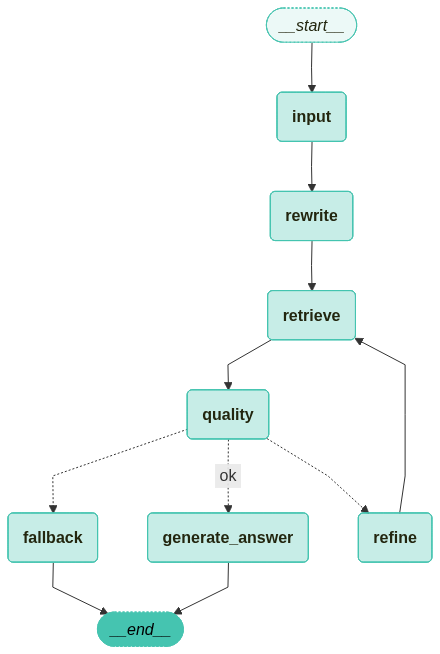

In [23]:
visualize_graph(app)

In [24]:
# 케이스 1: 잘 맞는 질의 (바로 OK 기대)
res1 = app.invoke(
    {"query":"포토리소그래피 공정의 기본 단계를 간단하게 설명해줘"},
    config={
        "callbacks":[lf_handler],
        "run_name":"Graph-OK",
        "tags":["ok"],
        "metadata":{"env":"colab"}}
)
print("=== 최종 답변(OK 케이스) ===\n", res1.get("answer",""))

=== 최종 답변(OK 케이스) ===
 포토리소그래피 공정은 웨이퍼에 포토레지스트(PR)를 코팅한 후, 마스크를 통해 노광하여 패턴을 형성합니다. 이후 현상(Develop) 과정을 통해 노광된 영역을 제거하고, 에칭(Etch)과 스트립(Strip) 단계를 통해 최종 회로 패턴을 완성합니다. 이 과정을 통해 반도체 소자의 미세한 구조를 구현할 수 있습니다.


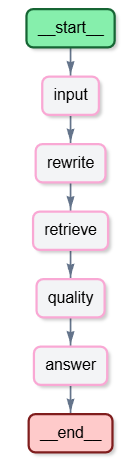

In [ ]:
# 케이스 2: 애매한 질의 (리파인/재시도 유도)
res2 = app.invoke(
    {"query":"패턴 그 공정?"},   # 의도적으로 모호
    config={"callbacks":[lf_handler],
            "run_name":"Graph-Refine-Retry",
            "tags":["retry??"],
            "metadata":{"env":"colab"}}
)
print("\n=== 최종 답변(Refine 케이스) ===\n", res2.get("answer",""))


=== 최종 답변(Refine 케이스) ===
 패턴 형성 공정은 반도체 제조에서 회로를 웨이퍼에 전사하는 과정입니다. 일반적으로 포토리소그래피 기술을 사용하여 감광성 물질(포토레지스트)을 웨이퍼에 도포한 후, 빛을 이용해 원하는 패턴을 형성하고, 이후 에칭 과정을 통해 이 패턴을 웨이퍼에 전사합니다. 이 과정은 반도체 소자의 미세한 구조를 형성하는 데 필수적입니다.


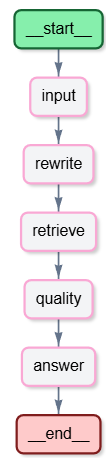

In [ ]:
# 케이스 3: 애매한 질의 (리파인/재시도 반복 유도)
res2 = app.invoke(
    {"query":"그 공정을 정확하게 설명해줘"},   # 의도적으로 모호
    config={"callbacks":[lf_handler],
            "run_name":"Graph-Refine-Retry2",
            "tags":["retry!!"],
            "metadata":{"env":"colab"}}
)
print("\n=== 최종 답변(Refine 케이스) ===\n", res2.get("answer",""))


=== 최종 답변(Refine 케이스) ===
 반도체 공정은 반도체 소자를 제조하기 위한 일련의 단계로 구성됩니다. 일반적으로 웨이퍼 준비, 산화, 포토리소그래피, 에칭, 도핑, 금속화 등의 과정이 포함되며, 각 단계는 소자의 전기적 특성을 형성하는 데 중요한 역할을 합니다. 이러한 공정들은 고도의 정밀성과 청정 환경에서 수행되어야 하며, 최종적으로는 고성능 반도체 소자가 생산됩니다.


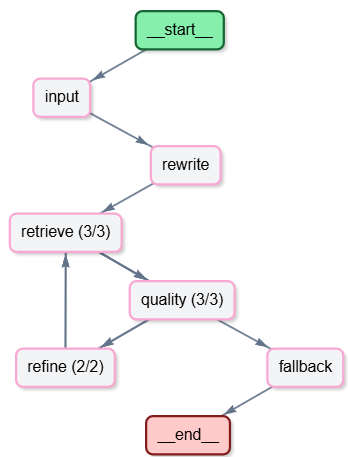

https://us.cloud.langfuse.com/project/cmgous6r600ukad07akufau4t/traces   


https://smith.langchain.com/o/77d9fcfa-dd76-4a16-a73c-2c5b815225f2/projects